Este trabajo utilizó ayuda de IA rpara la redaccion del markdown y el planteamiento del problema

# Solución numérica de la ecuación radial de Schrödinger para el átomo de hidrógeno mediante diferencias finitas

## Problema

Para el átomo de hidrógeno consideramos un electrón de masa $m$ que interactúa con un protón mediante el potencial Coulombiano

$$
U(r)=-\frac{e^2}{4\pi\epsilon_0}\frac{1}{r},
$$

donde:

- $e$ es la carga elemental.
- $\epsilon_0$ es la permitividad eléctrica del vacío.
- $r$ es la distancia entre el electrón y el protón.

La ecuación de Schrödinger independiente del tiempo es

$$
-\frac{\hbar^2}{2m}\nabla^2\psi(\mathbf r)
-\frac{e^2}{4\pi\epsilon_0r}\psi(\mathbf r)
=
E\psi(\mathbf r).
$$

El objetivo es resolver numéricamente esta ecuación utilizando el **método de diferencias finitas (FDM, Finite Difference Method)**.

En este ejercicio nos concentraremos exclusivamente en el caso

$$
\boxed{l=0}
$$

y calcularemos los cinco primeros estados:

$$
\boxed{n=1,2,3,4,5}.
$$

Estos corresponden a los estados

$$
\boxed{1s,\;2s,\;3s,\;4s,\;5s}.
$$


---

#Separación de variables

Debido a que el potencial Coulombiano depende únicamente de la distancia $r$, el problema posee simetría esférica.

Por esta razón podemos separar la función de onda en una parte radial y una parte angular:

$$
\psi(r,\theta,\phi)
=
R(r)Y_l^m(\theta,\phi),
$$

donde:

- $R(r)$ es la función radial.
- $Y_l^m(\theta,\phi)$ son los armónicos esféricos.
- $l$ es el número cuántico orbital.
- $m$ es el número cuántico magnético.

Después de realizar la separación de variables se obtiene la ecuación radial

$$
-\frac{\hbar^2}{2m}
\left[
\frac{1}{r^2}
\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right)
-
\frac{l(l+1)}{r^2}R
\right]
-
\frac{e^2}{4\pi\epsilon_0r}R
=
ER.
$$


---

# Transformación de la función radial

La ecuación anterior contiene el operador

$$
\frac{1}{r^2}
\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right),
$$

lo cual hace más complicada su discretización.

Por esta razón se introduce la función radial reducida

$$
\boxed{u(r)=rR(r)}.
$$

Por tanto,

$$
R(r)=\frac{u(r)}{r}.
$$

Al realizar esta transformación, la ecuación radial toma la forma

$$
-\frac{\hbar^2}{2m}
\frac{d^2u}{dr^2}
+
\left[
\frac{\hbar^2l(l+1)}{2mr^2}
-
\frac{e^2}{4\pi\epsilon_0r}
\right]u
=
Eu.
$$

Esta ecuación tiene una estructura similar a una ecuación de Schrödinger unidimensional:

$$
\boxed{
-\frac{\hbar^2}{2m}\frac{d^2u}{dr^2}
+
V_{\mathrm{eff}}(r)u
=
Eu
}
$$

donde

$$
V_{\mathrm{eff}}(r)
=
\frac{\hbar^2l(l+1)}{2mr^2}
-
\frac{e^2}{4\pi\epsilon_0r}
$$

es el **potencial efectivo**.


---


# Uso de unidades atómicas

Para simplificar el cálculo numérico utilizamos **unidades atómicas**.

La unidad natural de distancia es el radio de Bohr:

$$
\boxed{
a_0=
\frac{4\pi\epsilon_0\hbar^2}{me^2}
}.
$$

Definimos entonces la coordenada radial adimensional

$$
\boxed{
x=\frac{r}{a_0}
}.
$$


La unidad natural de energía es el Hartree:

$$
\boxed{
E_h=\frac{\hbar^2}{ma_0^2}
}.
$$

Escribimos la energía como

$$
E=E_h\varepsilon,
$$

donde $\varepsilon$ es la energía expresada en unidades de Hartree.

Al sustituir estas definiciones en la ecuación radial obtenemos

$$
-\frac{1}{2}\frac{d^2u}{dx^2}
+
\left[
\frac{l(l+1)}{2x^2}
-\frac{1}{x}
\right]u
=
\varepsilon u.
$$

Como estamos trabajando con $l=0$:

$$
\boxed{
-\frac{1}{2}\frac{d^2u}{dx^2}
-\frac{1}{x}u
=
\varepsilon u
}.
$$

Esta es la ecuación que resolveremos numéricamente.


---

# Solución analítica que utilizaremos como referencia

El átomo de hidrógeno tiene una solución analítica conocida para sus niveles de energía:

$$
\boxed{
E_n=-\frac{1}{2n^2}E_h
}.
$$

Como estamos usando unidades de Hartree, simplemente tenemos

$$
\boxed{
\varepsilon_n=-\frac{1}{2n^2}
}.
$$

Para los cinco primeros estados con $l=0$:

| Estado | $n$ | $l$ | Energía exacta (Hartree) |
|:---:|:---:|:---:|---:|
| $1s$ | 1 | 0 | $-0.500000$ |
| $2s$ | 2 | 0 | $-0.125000$ |
| $3s$ | 3 | 0 | $-0.055556$ |
| $4s$ | 4 | 0 | $-0.031250$ |
| $5s$ | 5 | 0 | $-0.020000$ |

Estos valores nos permiten comprobar qué tan bien funciona nuestra solución numérica.


---

# Discretización del espacio radial

Una computadora no puede trabajar directamente con un intervalo continuo.

Por lo tanto, reemplazamos el espacio radial por una malla de puntos:

$$
x_1,x_2,x_3,\ldots,x_N.
$$

La separación entre puntos será

$$
\boxed{
h=\Delta x=x_{i+1}-x_i
}.
$$

En el código utilizamos un valor máximo

$$
x_{\max}=50,
$$

por lo que estamos aproximando el intervalo

$$
0<x<50.
$$

El valor $x=50$ representa físicamente

$$
r=50a_0.
$$

Aunque el espacio físico se extiende hasta infinito, para estados ligados la función de onda disminuye rápidamente a cero. Por eso podemos reemplazar el infinito por un valor suficientemente grande de $x_{\max}$.


---

# Condiciones de frontera

La función radial reducida debe satisfacer

$$
\boxed{u(0)=0}.
$$

Además, para un estado ligado,

$$
u(r)\rightarrow0
\qquad
\text{cuando}
\qquad
r\rightarrow\infty.
$$

En nuestro cálculo sustituimos el infinito por $x_{\max}$:

$$
\boxed{u(x_{\max})=0}.
$$

Por lo tanto, las condiciones de frontera utilizadas son

$$
\boxed{
u(0)=0,
\qquad
u(x_{\max})=0
}.
$$

En el código no se utilizan directamente los puntos $x=0$ y $x=x_{\max}$ como puntos desconocidos. Se utilizan únicamente los puntos interiores de la malla.


---

# Aproximación de diferencias finitas

El único término diferencial de nuestra ecuación es

$$
\frac{d^2u}{dx^2}.
$$

Para aproximarlo utilizamos la diferencia finita centrada:

$$
\boxed{
\frac{d^2u}{dx^2}
\bigg|_{x_i}
\approx
\frac{
u_{i+1}-2u_i+u_{i-1}
}{h^2}
}.
$$

Sustituyendo esta aproximación en

$$
-\frac12\frac{d^2u}{dx^2}
-\frac1x u
=
Eu,
$$

obtenemos

$$
-\frac12
\frac{
u_{i+1}-2u_i+u_{i-1}
}{h^2}
-
\frac{1}{x_i}u_i
=
Eu_i.
$$

Distribuyendo el primer término:

$$
-\frac{1}{2h^2}u_{i+1}
+
\frac{1}{h^2}u_i
-
\frac{1}{2h^2}u_{i-1}
-
\frac{1}{x_i}u_i
=
Eu_i.
$$

Agrupando los términos:

$$
-\frac{1}{2h^2}u_{i-1}
+
\left(
\frac{1}{h^2}
-
\frac{1}{x_i}
\right)u_i
-
\frac{1}{2h^2}u_{i+1}
=
Eu_i.
$$


---

# Conversión a un problema de valores propios

La ecuación anterior puede escribirse en forma matricial como

$$
\boxed{
H\mathbf u=E\mathbf u
}.
$$

Aquí:

- $H$ es la matriz Hamiltoniana.
- $\mathbf u$ es el vector que contiene los valores de la función $u(x)$ en cada punto de la malla.
- $E$ es un valor propio de la matriz.

La matriz Hamiltoniana tiene una estructura tridiagonal:

$$
H=
\begin{pmatrix}
\frac{1}{h^2}-\frac{1}{x_1}
&
-\frac{1}{2h^2}
&
0
&
\cdots
\\[6pt]
-\frac{1}{2h^2}
&
\frac{1}{h^2}-\frac{1}{x_2}
&
-\frac{1}{2h^2}
&
\cdots
\\[6pt]
0
&
-\frac{1}{2h^2}
&
\frac{1}{h^2}-\frac{1}{x_3}
&
\cdots
\\
\vdots
&
\vdots
&
\vdots
&
\ddots
\end{pmatrix}.
$$

Los elementos de la diagonal principal son

$$
\boxed{
H_{ii}
=
\frac{1}{h^2}
-
\frac{1}{x_i}
}
$$

y los elementos inmediatamente por encima y por debajo de la diagonal son

$$
\boxed{
H_{i,i+1}
=
H_{i+1,i}
=
-\frac{1}{2h^2}
}.
$$

Todos los demás elementos son cero.


---

# Interpretación de los valores propios

Al resolver

$$
H\mathbf u_n=E_n\mathbf u_n,
$$

obtenemos varios valores propios:

$$
E_1,E_2,E_3,E_4,E_5,\ldots
$$

Los cinco valores propios más bajos corresponden a los cinco primeros estados ligados para $l=0$:

$$
\boxed{
1s,\;2s,\;3s,\;4s,\;5s
}.
$$

Por lo tanto:

$$
E_1\longrightarrow 1s,
$$

$$
E_2\longrightarrow 2s,
$$

$$
E_3\longrightarrow 3s,
$$

$$
E_4\longrightarrow 4s,
$$

$$
E_5\longrightarrow 5s.
$$

Los vectores propios asociados contienen las funciones de onda radiales reducidas:

$$
\mathbf u_1,\mathbf u_2,\ldots,\mathbf u_5.
$$


---

# Valores propios más pequeños

Los estados ligados del átomo de hidrógeno tienen energías negativas:

$$
E<0.
$$

El estado fundamental tiene la energía más negativa:

$$
E_{1s}=-0.5E_h.
$$

Después aparecen:

$$
E_{2s}=-0.125E_h,
$$

$$
E_{3s}\approx-0.05556E_h,
$$

etc.

Por lo tanto, necesitamos encontrar los valores propios más pequeños de la matriz Hamiltoniana.

En el código se utiliza:

```python
eigsh(H, k=num_states, which="SA")

Energías para l = 0
---------------------------------------------
Estado 1s: E_FDM = -0.49998751 Ha    E_exacta = -0.50000000 Ha
Estado 2s: E_FDM = -0.12499922 Ha    E_exacta = -0.12500000 Ha
Estado 3s: E_FDM = -0.05555539 Ha    E_exacta = -0.05555556 Ha
Estado 4s: E_FDM = -0.03120429 Ha    E_exacta = -0.03125000 Ha
Estado 5s: E_FDM = -0.01786473 Ha    E_exacta = -0.02000000 Ha


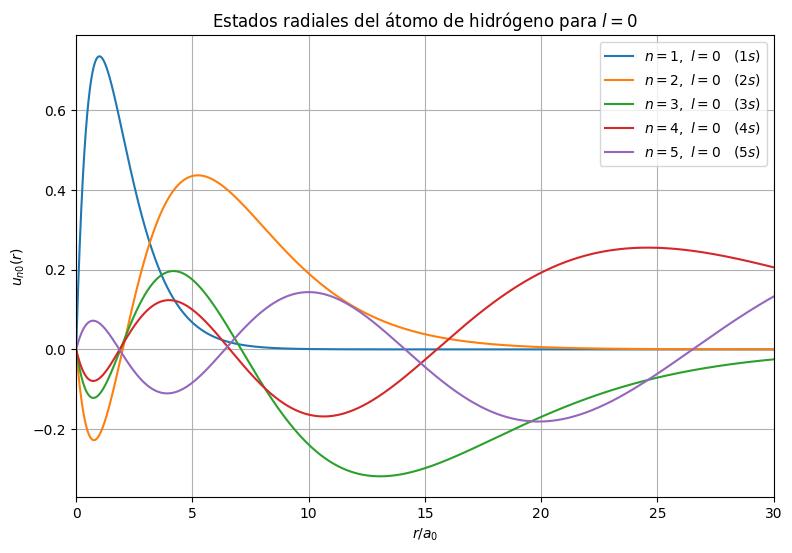

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# PARÁMETROS

l = 0                  # Número cuántico orbital fijo
x_max = 50.0           # r máximo en unidades de a0
N = 5000               # Número de puntos de la malla
num = 5         # Estados n = 1, 2, 3, 4, 5


# MALLA

x_full = np.linspace(0, x_max, N + 2)

# Eliminamos los extremos:
# u(0) = 0
# u(x_max) = 0

x = x_full[1:-1]

# Paso de la malla
h = x[1] - x[0]


# POTENCIAL EFECTIVO

# V_eff = l(l+1)/(2x^2) - 1/x

V = l * (l + 1) / (2 * x**2) - 1 / x


# HAMILTONIANO POR DIFERENCIAS FINITAS

# -1/2 d²u/dx²
#
# d²u/dx² ≈
# (u[i+1] - 2u[i] + u[i-1]) / h²

diagonal = 1 / h**2 + V

off_diagonal = -1 / (2 * h**2)


H = diags(
    [   off_diagonal * np.ones(N - 1),
        diagonal,
        off_diagonal * np.ones(N - 1)  ],
    offsets=[-1, 0, 1],
    format="csr"
)


# RESOLVER H u = E u

energies, wavef = eigsh(
    H,
    k=num,  #Para obtener los 5 mas pequeños algebraicamente
    which="SA"
)


# ORDENAR LOS ESTADOS POR ENERGÍA


orden = np.argsort(energies)

energies = energies[orden]
wavef = wavef[:, orden]


# NORMALIZAR LAS FUNCIONES DE ONDA

for i in range(num):

    u = wavef[:, i]
    norm = np.sqrt(np.trapezoid(u**2, x))

    wavef[:, i] = u / norm


print("Energías para l = 0")
print("-" * 45)

for i in range(num):

    n = i + 1

    E_fdm = energies[i]

    E_exacta = -1 / (2 * n**2)

    print( f"Estado {n}s: " f"E_FDM = {E_fdm:.8f} Ha    " f"E_exacta = {E_exacta:.8f} Ha")

In [ ]:
# GRAFICAR

plt.figure(figsize=(9, 6))

for i in range(num):

    n = i + 1

    u = wavef[:, i]

    plt.plot(
        x,
        u,
        label=fr"$n={n},\ l=0\quad ({n}s)$"
    )


plt.xlabel(r"$r/a_0$")
plt.ylabel(r"$u_{n0}(r)$")

plt.title(
    "Estados radiales del átomo de hidrógeno para $l=0$"
)

plt.xlim(0, 30)

plt.grid()

plt.legend()

plt.show()

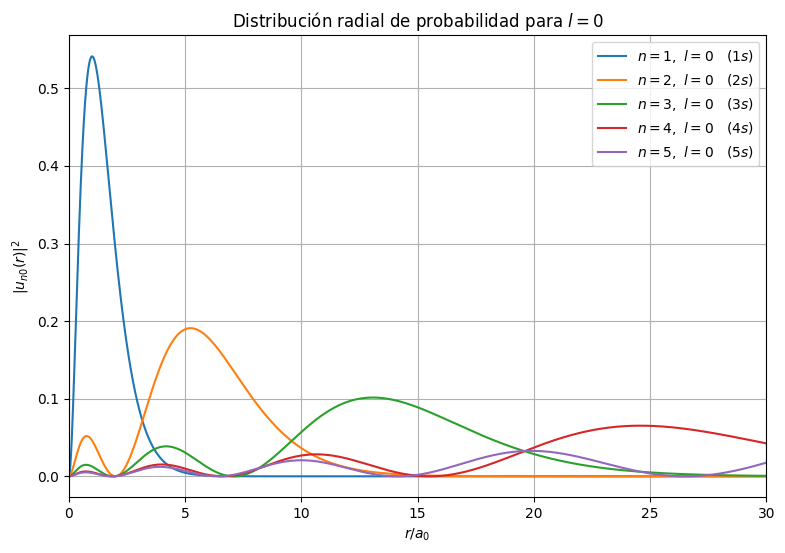

In [ ]:
#DISTRIBUCIÓN RADIAL DE PROBABILIDAD


plt.figure(figsize=(9, 6))

for i in range(num_states):

    n = i + 1

    # Función radial reducida u(r)
    u = wavefunctions[:, i]

    # Probabilidad radial
    probability = np.abs(u)**2

    plt.plot(
        x,
        probability,
        label=fr"$n={n},\ l=0\quad ({n}s)$"
    )


plt.xlabel(r"$r/a_0$")
plt.ylabel(r"$|u_{n0}(r)|^2$")

plt.title("Distribución radial de probabilidad para $l=0$")
plt.xlim(0, 30)
plt.grid()
plt.legend()
plt.show()